In [25]:
""" 
IMPORTS
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

# Get my functions
from segmentation_functions import idxs_from_files

# Parameters

In [26]:
""" LOAD DESIGN MATRICES """
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/'
base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'  # TODO: perhaps should rerun?
# base_path ='/home/ines/repositories/representation_learning_variability/paper-individuality/data/training/'

data_path = base_path + 'design_matrices/'  # TODO: perhaps should rerun design matrices?
# data_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/design_matrices/1_camera_setup/session_1/'
# data_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/design_matrices/1_camera_setup/extra_bwm/'

all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

""" FITTING PARAMETERS HMMs """
num_train_batches = 5
method='prior'
fit_method='em'
whisker_params = str(num_train_batches)+'_'+method+'_'+fit_method+'_zsc_'+'True/'
licking_params = str(num_train_batches)+'_'+method+'_'+fit_method+'_zsc_'+'False/'

states_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/hmm/most_likely_states/'
states_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/hmm/most_likely_states/'  # TODO: perhaps should rerun?
# states_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/training/hmm/most_likely_states/' 

""" FITTING PARAMETERS WAVELET CLUSTERS """
optimal_k = 8  # 4 for learning
optimal_k_wheel = 4
var = 'left_paw'  # 'left_paw' for learning
zsc = True  # Whether to z-score the data before PCA and clustering

paw_wavelet_path = base_path + 'paw_wavelets/'  # holds l_paw_* / r_paw_* wavelet coefficients

paw_wavelet_states_path = base_path + 'paw_states_session_zscored/' if zsc else base_path + 'paw_state/'
left_paw_wavelet_states_path = base_path + 'left_paw_states_session_zscored/' if zsc else base_path + 'left_paw_state/'
wheel_wavelet_states_path = base_path + 'wheel_states_session_zscored/' if zsc else base_path + 'wheel_states/'


include_wheel = False
save_states_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/states_files/'
save_states_path = base_path + 'states_files/'
# save_states_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/training/states_files/'
# save_states_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/training/biased_extra_bwm/states_files/'

# Functions

In [27]:
def build_paw_state_dataset(states_trial, session, mouse_name, paw_wavelet_path):
    """Merge wheel velocity + left-paw wavelet features with the paw-state target for one session.

    The paw state is the first digit of `identifiable_states` (paw + whisker + lick states
    concatenated). It was originally estimated from BOTH paws, so predicting it from left-paw +
    wheel tests how well it can be recovered without the right paw.

    Returns (data, X, y, feature_cols, classes), or (None, ...) if the wavelet file is missing.
    """
    # Discovery bands only: 0.5-8.0 Hz. These are the exact scales fed to PCA+KMeans in
    # 3.3_wavelet_clusters.ipynb (final `var_interest`), i.e. the space the clusters were defined
    # in. The 0.25/16.0/32.0 columns exist in the file but were never used to define the clusters.
    wavelet_scales = ['0.5', '1.0', '2.0', '4.0', '8.0']
    left_paw_cols = [f'l_paw_{axis}{scale}' for axis in ('x', 'y') for scale in wavelet_scales]
    feature_cols = ['avg_wheel_vel'] + left_paw_cols

    wavelet_file = paw_wavelet_path + "paw_vel_wavelets_" + str(session) + '_' + mouse_name
    if not Path(wavelet_file).exists():
        return None, None, None, feature_cols, None
    wavelets = pd.read_parquet(wavelet_file)

    # Merge wavelet features onto the states file (aligned on Bin) and build the target
    data = states_trial[['Bin', 'avg_wheel_vel', 'identifiable_states']].merge(
        wavelets[['Bin'] + left_paw_cols], on='Bin', how='inner')
    data['paw_state'] = data['identifiable_states'].astype(str).str[0]

    # Keep only rows with a valid paw state and no missing features
    data = data[data['paw_state'].str.isdigit()].copy()
    data = data.dropna(subset=feature_cols)
    data['paw_state'] = data['paw_state'].astype(int)

    X = data[feature_cols].to_numpy()
    y = data['paw_state'].to_numpy()
    classes = np.unique(y)
    return data, X, y, feature_cols, classes


def cross_validate_paw_state(X, y, n_splits=5, n_estimators=100, random_state=0):
    """Stratified k-fold CV. Returns out-of-fold predictions and a metrics dict."""
    clf = RandomForestClassifier(n_estimators=n_estimators, n_jobs=-1, random_state=random_state)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    y_pred = cross_val_predict(clf, X, y, cv=cv, n_jobs=-1)
    metrics = {
        'accuracy': accuracy_score(y, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y, y_pred),
        'majority_chance': np.bincount(y).max() / len(y),   # always-predict-most-common baseline
        'uniform_chance': 1 / len(np.unique(y)),            # baseline for balanced accuracy
    }
    return y_pred, metrics


def plot_paw_state_confusion(y, y_pred, classes, metrics, mouse_name, session):
    """(1) Row-normalized confusion matrix + per-state recall vs chance baselines."""
    cm = confusion_matrix(y, y_pred, labels=classes)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)          # row-normalized -> per-state recall
    per_class_recall = np.diag(cm_norm)

    fig, (ax_cm, ax_acc) = plt.subplots(1, 2, figsize=(14, 5.5))

    # Confusion matrix heatmap
    im = ax_cm.imshow(cm_norm, cmap='viridis', vmin=0, vmax=1)
    ax_cm.set_xticks(range(len(classes)), classes)
    ax_cm.set_yticks(range(len(classes)), classes)
    ax_cm.set_xlabel('Predicted paw state')
    ax_cm.set_ylabel('True paw state')
    ax_cm.set_title(f'Confusion matrix (row-normalized)\n{mouse_name} {session[:8]}')
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax_cm.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center',
                       color='white' if cm_norm[i, j] < 0.6 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04, label='fraction of true state')

    # Per-state recall + overall accuracy vs chance
    ax_acc.bar(range(len(classes)), per_class_recall, color='tab:blue', alpha=0.8)
    ax_acc.axhline(metrics['accuracy'], color='k', ls='--', lw=1.5,
                   label=f"overall accuracy = {metrics['accuracy']:.2f}")
    ax_acc.axhline(metrics['balanced_accuracy'], color='tab:green', ls='--', lw=1.5,
                   label=f"balanced accuracy = {metrics['balanced_accuracy']:.2f}")
    ax_acc.axhline(metrics['majority_chance'], color='tab:red', ls=':', lw=1.5,
                   label=f"majority-class chance = {metrics['majority_chance']:.2f}")
    ax_acc.axhline(metrics['uniform_chance'], color='grey', ls=':', lw=1.5,
                   label=f"uniform chance = {metrics['uniform_chance']:.2f}")
    ax_acc.set_xticks(range(len(classes)), classes)
    ax_acc.set_xlabel('Paw state')
    ax_acc.set_ylabel('Recall (per-state accuracy)')
    ax_acc.set_ylim(0, 1.05)
    ax_acc.set_title('Decoding accuracy per state')
    ax_acc.legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.show()


def plot_paw_state_snippets(states_trial, data, classes, mouse_name, session,
                            window=800, n_snippets=1):
    """(2) True vs predicted state over the raw wheel / L-paw / R-paw x velocities (overlaid).

    In the signal panel the background is split at y=0: the TRUE state shades the top half and
    the PREDICTED state shades the bottom half, so mismatches show as a color change across y=0.
    """
    # Full-session plotting frame (sorted by time) with paw x-velocities and predictions
    plot_df = states_trial[['Bin', 'avg_wheel_vel', 'l_paw_x', 'r_paw_x']].sort_values('Bin').reset_index(drop=True)
    plot_df['l_paw_x_vel'] = plot_df['l_paw_x'].diff()
    plot_df['r_paw_x_vel'] = plot_df['r_paw_x'].diff()
    plot_df = plot_df.merge(data[['Bin', 'paw_state', 'pred_state']], on='Bin', how='left')

    # Split into contiguous recording segments (gaps between trials break continuity)
    bin_dt = np.median(np.diff(plot_df['Bin']))
    plot_df['segment'] = (plot_df['Bin'].diff() > 1.5 * bin_dt).cumsum()

    # Candidate non-overlapping windows (within one segment) that contain several states
    candidates = []
    for _, g in plot_df.groupby('segment'):
        g = g.dropna(subset=['paw_state', 'pred_state'])
        for start in range(0, len(g) - window + 1, window):
            seg = g.iloc[start:start + window]
            if seg['paw_state'].nunique() >= 4:
                candidates.append(seg)

    # Evenly spaced pick so snippets span the session rather than clustering at the start
    if len(candidates) > n_snippets:
        idx = np.linspace(0, len(candidates) - 1, n_snippets).round().astype(int)
        snippets = [candidates[i] for i in idx]
    else:
        snippets = candidates
    print(f"{len(candidates)} candidate windows, showing {len(snippets)}")

    # Consistent colors per state (shared across true/predicted)
    palette = ListedColormap(sns.color_palette('Set2', n_colors=8))
    state_colors = {s: palette(int(s)) for s in classes}

    def shade_by_state(ax, t, states, ymin=0.0, ymax=1.0):
        """Shade a horizontal band (ymin..ymax in axes fraction) by (integer) state value."""
        vals = states.to_numpy()
        tt = t.to_numpy()
        start = 0
        for i in range(1, len(vals) + 1):
            if i == len(vals) or vals[i] != vals[start]:
                if not np.isnan(vals[start]):
                    ax.axvspan(tt[start], tt[i - 1], ymin=ymin, ymax=ymax,
                               color=state_colors[int(vals[start])], alpha=0.35, lw=0, zorder=0)
                start = i

    def znorm(x):
        x = x.to_numpy(dtype=float)
        sd = np.nanstd(x)
        return (x - np.nanmean(x)) / sd if sd > 0 else x - np.nanmean(x)

    raw_signals = [('avg_wheel_vel', 'tab:blue', 'wheel velocity'),
                   ('l_paw_x_vel', '#D8971F', 'L paw x velocity'),
                   ('r_paw_x_vel', '#54AA0E', 'R paw x velocity')]

    for k, seg in enumerate(snippets):
        t = seg['Bin']
        fig, axes = plt.subplots(2, 1, sharex=True, figsize=(13, 6),
                                 gridspec_kw={'height_ratios': [1.3, 2]})

        # Top: true vs predicted state as step lines
        axes[0].step(t, seg['paw_state'], where='post', color='k', lw=1.5, label='true')
        axes[0].step(t, seg['pred_state'], where='post', color='tab:red', lw=1.2, alpha=0.8, label='predicted')
        axes[0].set_yticks(classes)
        axes[0].set_ylabel('paw state')
        axes[0].legend(loc='upper right', ncol=2, fontsize=8)
        axes[0].set_title(f'Snippet {k + 1}: true vs predicted paw state — {mouse_name} {session[:8]}')

        # Bottom: all raw signals (z-scored) overlaid.
        # Background split at y=0: true state shades the top half, predicted the bottom half.
        ax_sig = axes[1]
        for col, color, lab in raw_signals:
            ax_sig.plot(t, znorm(seg[col]), color=color, lw=0.9, label=lab)
        ylo, yhi = ax_sig.get_ylim()
        frac0 = float(np.clip((0 - ylo) / (yhi - ylo), 0, 1)) if yhi > ylo else 0.5
        shade_by_state(ax_sig, t, seg['paw_state'], ymin=frac0, ymax=1.0)   # true -> top half
        shade_by_state(ax_sig, t, seg['pred_state'], ymin=0.0, ymax=frac0)  # predicted -> bottom half
        ax_sig.axhline(0, color='k', lw=0.6, alpha=0.6)
        ax_sig.set_ylim(ylo, yhi)
        ax_sig.text(0.004, 0.97, 'true', transform=ax_sig.transAxes, va='top', ha='left', fontsize=7)
        ax_sig.text(0.004, 0.03, 'predicted', transform=ax_sig.transAxes, va='bottom', ha='left', fontsize=7)
        ax_sig.set_ylabel('z-scored signal')
        ax_sig.set_xlabel('Time (s)')
        ax_sig.legend(loc='upper right', ncol=3, fontsize=8)

        plt.tight_layout()
        plt.show()

In [28]:
def evaluate_paw_state_session(states_trial, session, mouse_name, paw_wavelet_path,
                               n_splits=5, n_estimators=100, random_state=0):
    """Cross-validate the paw-state classifier for one session (no plotting).

    Returns (summary, per_state):
      summary   : dict of session-level metrics (accuracy, balanced_accuracy, chances, sizes)
      per_state : DataFrame with one row per paw state (recall + support)
    Returns (None, None) if the session has no usable data / fewer than 2 states.
    """
    data, X, y, feature_cols, classes = build_paw_state_dataset(
        states_trial, session, mouse_name, paw_wavelet_path)
    if data is None or classes is None or len(classes) < 2:
        return None, None

    y_pred, metrics = cross_validate_paw_state(X, y, n_splits, n_estimators, random_state)

    cm = confusion_matrix(y, y_pred, labels=classes)
    support = cm.sum(axis=1)
    recall = np.divide(np.diag(cm), support, out=np.full(len(classes), np.nan, dtype=float),
                       where=support > 0)

    summary = {'mouse_name': mouse_name, 'session': session,
               'n_samples': len(y), 'n_states': len(classes), **metrics}
    per_state = pd.DataFrame({'mouse_name': mouse_name, 'session': session,
                              'paw_state': classes.astype(int),
                              'recall': recall, 'support': support})
    return summary, per_state


def plot_paw_state_accuracy_summary(session_metrics, per_state_recall):
    """Aggregate decoder statistics across sessions:
       (left)  overall & balanced accuracy distribution across sessions
       (right) mean per-state recall (+/- SEM) across sessions, with per-session points."""
    n_sessions = len(session_metrics)
    rng = np.random.default_rng(0)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: overall vs balanced accuracy across sessions
    box_data = [session_metrics['accuracy'].to_numpy(),
                session_metrics['balanced_accuracy'].to_numpy()]
    ax1.boxplot(box_data, showfliers=False)
    ax1.set_xticks([1, 2], ['accuracy', 'balanced\naccuracy'])
    for i, vals in enumerate(box_data, start=1):
        ax1.scatter(i + (rng.random(len(vals)) - 0.5) * 0.25, vals, color='k', s=10, alpha=0.4)
    ax1.axhline(session_metrics['majority_chance'].mean(), color='tab:red', ls=':', lw=1.5,
                label=f"mean majority chance = {session_metrics['majority_chance'].mean():.2f}")
    ax1.set_ylabel('score')
    ax1.set_ylim(0, 1.02)
    ax1.set_title(f'Decoding accuracy across {n_sessions} sessions')
    ax1.legend(fontsize=8, loc='lower right')

    # Right: mean per-state recall across sessions (+/- SEM), with per-session points
    states_sorted = sorted(per_state_recall['paw_state'].unique())
    agg = (per_state_recall.groupby('paw_state')['recall']
           .agg(['mean', 'std', 'count']).reindex(states_sorted))
    agg['sem'] = agg['std'] / np.sqrt(agg['count'])
    x = np.arange(len(states_sorted))
    palette = ListedColormap(sns.color_palette('Set2', n_colors=8))
    colors = [palette(int(s)) for s in states_sorted]

    ax2.bar(x, agg['mean'], yerr=agg['sem'], color=colors, alpha=0.85, capsize=3)
    pos = {s: i for i, s in enumerate(states_sorted)}
    xj = per_state_recall['paw_state'].map(pos).to_numpy() + (rng.random(len(per_state_recall)) - 0.5) * 0.3
    ax2.scatter(xj, per_state_recall['recall'], color='k', s=8, alpha=0.3)
    ax2.set_xticks(x, states_sorted)
    ax2.set_xlabel('paw state')
    ax2.set_ylabel('recall (per-state accuracy)')
    ax2.set_ylim(0, 1.02)
    ax2.set_title(f'Mean per-state decoding accuracy (±SEM), n={n_sessions} sessions')

    plt.tight_layout()
    plt.show()

In [29]:
# ----- Cross-session (super-session) training & leave-one-group-out CV -----

def zscore_wavelets_per_session(data, wavelet_cols):
    """Per-session z-score of the wavelet columns (scheme B).

    Stats (mean/std) come from THIS session's own rows, so the transform is label-free and is
    applied identically to training and held-out sessions -- the held-out session is z-scored by
    ITS OWN stats, never the training set's. This is exactly what happens at deployment (a new
    session standardizes against itself), so it is leakage-free.
    """
    data = data.copy()
    mu = data[wavelet_cols].mean()
    sd = data[wavelet_cols].std().replace(0, 1)
    data[wavelet_cols] = (data[wavelet_cols] - mu) / sd
    return data


def load_sessions_for_cv(sessions_to_process, save_states_path, optimal_k, paw_wavelet_path,
                         n_sessions=8, zscore_wavelets=True):
    """Load sessions into a dict {(session, mouse): data} for cross-session CV.

    Per-session z-scores the paw-wavelet columns (scheme B) at load time. Returns
    (session_data, feature_cols).
    """
    session_data = {}
    feature_cols = None
    for mat in sessions_to_process:
        if len(session_data) >= n_sessions:
            break
        mouse_name, session = mat[0], mat[1]
        p = save_states_path + str(optimal_k) + "_states_file_" + str(session) + '_' + mouse_name
        if not Path(p).exists():
            continue
        states_trial = pd.read_parquet(p)
        data, X, y, feature_cols, classes = build_paw_state_dataset(
            states_trial, session, mouse_name, paw_wavelet_path)
        if data is None or classes is None or len(classes) < 2:
            continue
        if zscore_wavelets:
            wavelet_cols = [c for c in feature_cols if c != 'avg_wheel_vel']
            data = zscore_wavelets_per_session(data, wavelet_cols)
        session_data[(session, mouse_name)] = data
        print(f"loaded {mouse_name} {session[:8]} ({len(data)} rows)")
    print(f"{len(session_data)} sessions loaded for CV.")
    return session_data, feature_cols


def leave_one_group_out_cv(session_data, feature_cols, group_by='session',
                           n_sub=5000, n_estimators=100, random_state=0,
                           global_scaler=False, pca_variance=None):
    """Leave-one-group-out cross-session CV.

    Each fold builds a super-session = subsample (n_sub rows) of every OTHER group's sessions
    pooled together, trains on it, and predicts the ENTIRE held-out group. Iterating over groups
    just repeats "train on many, test on one unseen" and averages, so no single test session
    dominates the estimate.

    group_by : 'session' -> leave-one-session-out (new-session deployment)
               'mouse'   -> leave-one-mouse-out: hold out ALL sessions of a mouse (new-mouse
                            deployment). Stricter, because same-mouse sessions share idiosyncrasies
                            that plain LOSO would leak across the train/test split.

    Discovery-faithful extras (mirror 3.3_wavelet_clusters.ipynb), both fit on TRAIN ONLY so the
    held-out group never informs them:
      global_scaler : fit a StandardScaler on the train super-session (no-op for RandomForest).
      pca_variance  : if set (e.g. 0.95), fit PCA on train to keep that fraction of variance.
    """
    keys = list(session_data.keys())
    group_of = {k: (k[1] if group_by == 'mouse' else k) for k in keys}
    groups = sorted(set(group_of.values()), key=str)

    fold_rows, per_state_rows = [], []
    for held in groups:
        train_keys = [k for k in keys if group_of[k] != held]
        test_keys = [k for k in keys if group_of[k] == held]
        if not train_keys or not test_keys:
            continue

        train = pd.concat([session_data[k].sample(n=min(n_sub, len(session_data[k])),
                                                  random_state=random_state)
                           for k in train_keys], ignore_index=True)
        test = pd.concat([session_data[k] for k in test_keys], ignore_index=True)

        Xtr, ytr = train[feature_cols].to_numpy(), train['paw_state'].to_numpy()
        Xte, yte = test[feature_cols].to_numpy(), test['paw_state'].to_numpy()

        # Optional discovery-faithful steps -- fit on TRAIN ONLY, applied to the held-out group
        if global_scaler:
            scaler = StandardScaler().fit(Xtr)
            Xtr, Xte = scaler.transform(Xtr), scaler.transform(Xte)
        if pca_variance is not None:
            pca = PCA(n_components=pca_variance, svd_solver='full').fit(Xtr)
            Xtr, Xte = pca.transform(Xtr), pca.transform(Xte)

        clf = RandomForestClassifier(n_estimators=n_estimators, n_jobs=-1,
                                     random_state=random_state).fit(Xtr, ytr)
        y_pred = clf.predict(Xte)

        held_label = held if group_by == 'mouse' else held[1]
        fold_rows.append({'mouse_name': held_label,
                          'session': ('' if group_by == 'mouse' else held[0]),
                          'accuracy': accuracy_score(yte, y_pred),
                          'balanced_accuracy': balanced_accuracy_score(yte, y_pred),
                          'majority_chance': np.bincount(yte).max() / len(yte),
                          'n_test': len(yte)})
        classes = np.unique(yte)
        cm = confusion_matrix(yte, y_pred, labels=classes)
        support = cm.sum(axis=1)
        recall = np.divide(np.diag(cm), support, out=np.full(len(classes), np.nan, dtype=float),
                           where=support > 0)
        for s, r in zip(classes, recall):
            per_state_rows.append({'held': str(held_label), 'paw_state': int(s), 'recall': r})

    return pd.DataFrame(fold_rows), pd.DataFrame(per_state_rows)

# Individual sessions

In [30]:
# Identify sessions available to process
sessions_to_process = []
for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]
    fit_id = str(mouse_name + session)
    whisker_filename = os.path.join(states_path + whisker_params, 'whisker_me' + '_' + fit_id)
    licks_filename = os.path.join(states_path + licking_params, 'Lick count' + '_' + fit_id)
    if var == 'left_paw':
        paw_wavelet_filename = os.path.join(left_paw_wavelet_states_path, "most_likely_states_" + str(optimal_k) + '_' + fit_id+'.npy')
    elif var == 'paw':
        paw_wavelet_filename = os.path.join(paw_wavelet_states_path, "most_likely_states_" + str(optimal_k) + '_' + fit_id+'.npy')
    wheel_wavelet_filename = os.path.join(wheel_wavelet_states_path, "most_likely_states_" + str(optimal_k_wheel) + '_' + fit_id+'.npy')

    if include_wheel:
        if os.path.exists(whisker_filename) and os.path.exists(licks_filename) and os.path.exists(paw_wavelet_filename) and os.path.exists(wheel_wavelet_filename):
            sessions_to_process.append((mouse_name, session))
    else:
        if os.path.exists(whisker_filename) and os.path.exists(licks_filename):
            sessions_to_process.append((mouse_name, session))

print(f"Found {len(sessions_to_process)} sessions to process.")

Found 319 sessions to process.


In [18]:
for m, mat in enumerate(sessions_to_process):

    mouse_name = mat[0]
    session = mat[1]
    fit_id = str(mouse_name + session)

    # Load session-specific states file
    session_file_path = save_states_path + str(optimal_k) + "_states_file_" + str(session) + '_' + mouse_name
    if not Path(session_file_path).exists():
        continue
    states_trial = pd.read_parquet(session_file_path)

    # Build features (wheel + left-paw wavelets) and target (paw state)
    data, X, y, feature_cols, classes = build_paw_state_dataset(
        states_trial, session, mouse_name, paw_wavelet_path)
    if data is None:
        print(f"{mouse_name} {session}: no wavelet file, skipping")
        continue

    # Cross-validated classifier
    y_pred, metrics = cross_validate_paw_state(X, y)
    data['pred_state'] = y_pred          # aligned row-for-row with y (Bin kept for plotting)

    print(f"{mouse_name} {session}: {len(y)} samples, {X.shape[1]} features, "
          f"{len(classes)} paw states {classes}")
    print(f"CV accuracy: {metrics['accuracy']:.3f} (majority-class chance {metrics['majority_chance']:.3f})")
    print(f"CV balanced accuracy: {metrics['balanced_accuracy']:.3f} (uniform chance {metrics['uniform_chance']:.3f})")

    # Visualize
    plot_paw_state_confusion(y, y_pred, classes, metrics, mouse_name, session)
    plot_paw_state_snippets(states_trial, data, classes, mouse_name, session)

KeyboardInterrupt: 

# Across sessions

Run the classifier on every session and collect metrics (no per-session plots), then plot
average decoding accuracy overall and per state.

In [20]:
# Cross-validate every session and collect per-session + per-state metrics.
# NOTE: this re-runs the classifier per session (~30-60 s each). Set max_sessions to an int
#       to subsample while prototyping; None runs all. Lower n_estimators to speed it up.
max_sessions = 20          # e.g. 20 to test; None = all
n_estimators = 100

use_sessions = sessions_to_process if max_sessions is None else sessions_to_process[:max_sessions]
summaries, per_state_rows = [], []
for m, mat in enumerate(use_sessions):
    mouse_name, session = mat[0], mat[1]
    session_file_path = save_states_path + str(optimal_k) + "_states_file_" + str(session) + '_' + mouse_name
    if not Path(session_file_path).exists():
        continue
    states_trial = pd.read_parquet(session_file_path)

    summary, per_state = evaluate_paw_state_session(
        states_trial, session, mouse_name, paw_wavelet_path, n_estimators=n_estimators)
    if summary is None:
        continue
    summaries.append(summary)
    per_state_rows.append(per_state)
    print(f"[{m + 1}/{len(use_sessions)}] {mouse_name} {session[:8]}: "
          f"acc={summary['accuracy']:.3f} bal_acc={summary['balanced_accuracy']:.3f}")

session_metrics = pd.DataFrame(summaries)
per_state_recall = pd.concat(per_state_rows, ignore_index=True)
print(f"\nProcessed {len(session_metrics)} sessions.")

[1/20] DY_011 36280321: acc=0.972 bal_acc=0.945
[2/20] DY_009 db4df448: acc=0.980 bal_acc=0.945
[3/20] ZFM-02372 88224abb: acc=0.971 bal_acc=0.930
[4/20] DY_010 bb6a5aae: acc=0.961 bal_acc=0.932
[5/20] SWC_054 671c7ea7: acc=0.972 bal_acc=0.903
[6/20] PL033 9fc31d79: acc=0.974 bal_acc=0.952
[7/20] CSH_ZAD_026 15763234: acc=0.970 bal_acc=0.926
[8/20] NR_0027 ae8787b1: acc=0.951 bal_acc=0.916
[9/20] ZFM-01936 2c44a360: acc=0.964 bal_acc=0.931
[10/20] PL033 a34b4013: acc=0.953 bal_acc=0.928
[11/20] DY_013 2f63c555: acc=0.982 bal_acc=0.943
[12/20] SWC_043 6f09ba7e: acc=0.966 bal_acc=0.938
[13/20] CSH_ZAD_026 e56541a5: acc=0.972 bal_acc=0.929
[14/20] ibl_witten_29 821f1883: acc=0.967 bal_acc=0.943
[15/20] NYU-47 fc43390d: acc=0.966 bal_acc=0.938
[16/20] DY_010 90d1e82c: acc=0.967 bal_acc=0.941
[17/20] NYU-12 a8a8af78: acc=0.967 bal_acc=0.930
[18/20] CSHL052 83e77b4b: acc=0.955 bal_acc=0.882
[19/20] PL033 49250fba: acc=0.958 bal_acc=0.938
[20/20] SWC_054 56b57c38: acc=0.978 bal_acc=0.884

Pro

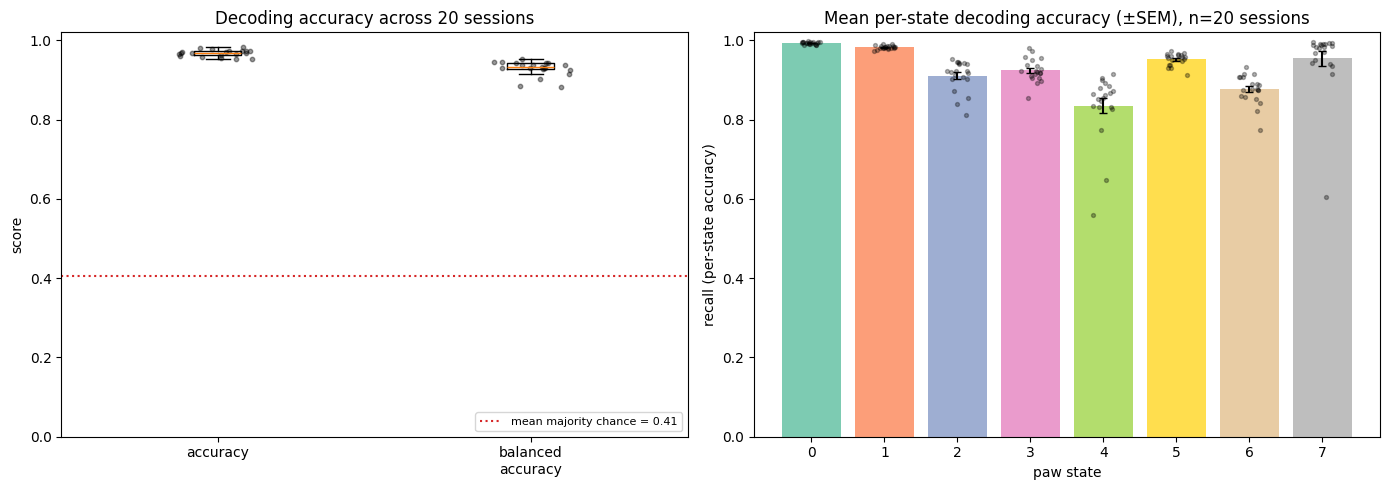

            mean    std  count
paw_state                     
0          0.993  0.003     20
1          0.982  0.004     20
2          0.911  0.038     20
3          0.925  0.029     20
4          0.835  0.087     20
5          0.952  0.015     20
6          0.877  0.037     20
7          0.954  0.085     20


In [21]:
# Aggregate statistics across sessions
plot_paw_state_accuracy_summary(session_metrics, per_state_recall)

# Mean per-state recall (numeric)
print(per_state_recall.groupby('paw_state')['recall'].agg(['mean', 'std', 'count']).round(3))

# Cross-session generalization (super-session + leave-one-group-out CV)

Train on a super-session (subsample of many sessions pooled) and predict an entire held-out
session/mouse — the honest estimate for deploying on new data. Paw wavelets are per-session
z-scored (scheme B); optional train-only global scaler + PCA mirror the discovery pipeline.

In [33]:
# Config for the cross-session evaluation (prototype with a handful of sessions)
n_cv_sessions = 20        # how many sessions to load
n_sub = 5000             # rows sampled per training session for the super-session
group_by = 'session'     # 'session' = leave-one-session-out; 'mouse' = leave-one-mouse-out
zscore_wavelets = True   # scheme B: per-session z-score of paw wavelets (held-out uses its own stats)
global_scaler = False    # discovery-faithful add-on, train-only (no-op for RandomForest)
pca_variance = None      # e.g. 0.95 for train-only PCA (mirrors 3.3 discovery); None = off

session_data, cv_feature_cols = load_sessions_for_cv(
    sessions_to_process, save_states_path, optimal_k, paw_wavelet_path,
    n_sessions=n_cv_sessions, zscore_wavelets=zscore_wavelets)

loaded DY_011 36280321 (194245 rows)
loaded DY_009 db4df448 (206695 rows)
loaded ZFM-02372 88224abb (281260 rows)
loaded DY_010 bb6a5aae (132765 rows)
loaded SWC_054 671c7ea7 (291497 rows)
loaded PL033 9fc31d79 (215360 rows)
loaded CSH_ZAD_026 15763234 (360695 rows)
loaded NR_0027 ae8787b1 (322925 rows)
loaded ZFM-01936 2c44a360 (246650 rows)
loaded PL033 a34b4013 (282200 rows)
loaded DY_013 2f63c555 (286495 rows)
loaded SWC_043 6f09ba7e (247995 rows)
loaded CSH_ZAD_026 e56541a5 (280875 rows)
loaded ibl_witten_29 821f1883 (251670 rows)
loaded NYU-47 fc43390d (281840 rows)
loaded DY_010 90d1e82c (165460 rows)
loaded NYU-12 a8a8af78 (224505 rows)
loaded CSHL052 83e77b4b (306405 rows)
loaded PL033 49250fba (253715 rows)
loaded SWC_054 56b57c38 (240735 rows)
20 sessions loaded for CV.


   mouse_name                              session  accuracy  balanced_accuracy  majority_chance  n_test
  CSH_ZAD_026 15763234-d21e-491f-a01b-1238eb96d389     0.809              0.567            0.445  360695
    ZFM-01936 2c44a360-5a56-4971-8009-f469fb59de98     0.761              0.531            0.401  246650
       DY_013 2f63c555-eb74-4d8d-ada5-5c3ecf3b46be     0.801              0.523            0.471  286495
       DY_011 36280321-555b-446d-9b7d-c2e17991e090     0.777              0.566            0.418  194245
        PL033 49250fba-801c-4867-a0a7-a1e19538cb61     0.731              0.576            0.343  253715
      SWC_054 56b57c38-2699-4091-90a8-aba35103155e     0.818              0.571            0.358  240735
      SWC_054 671c7ea7-6726-4fbe-adeb-f89c2c8e489b     0.767              0.527            0.358  291497
      SWC_043 6f09ba7e-e3ce-44b0-932b-c003fb44fb89     0.760              0.614            0.418  247995
ibl_witten_29 821f1883-27f3-411d-afd3-fb8241bbc39a     

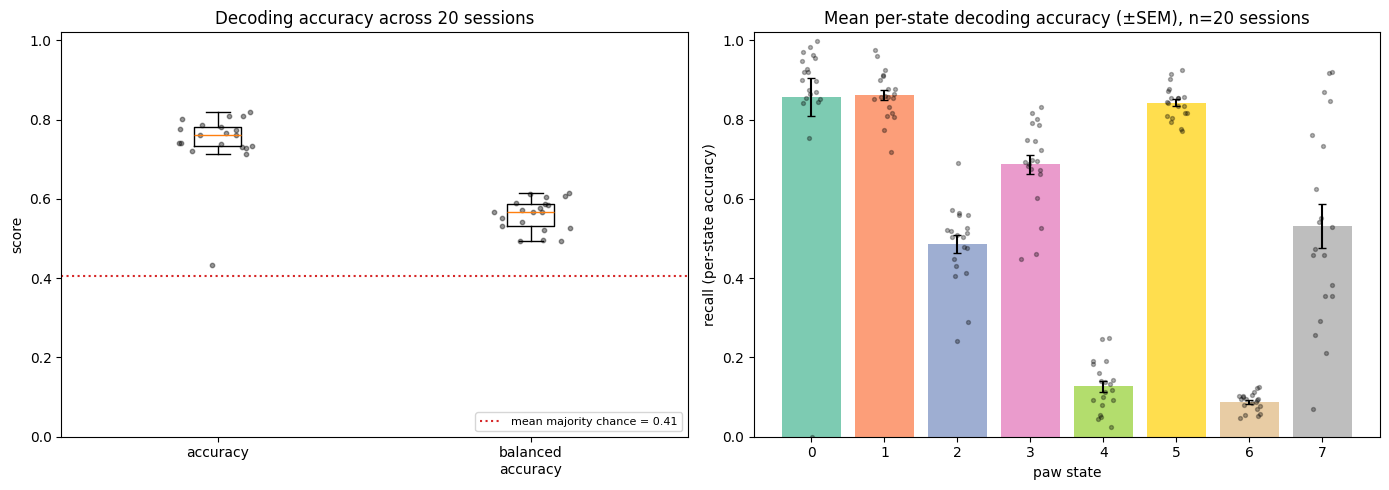

In [34]:
# Run leave-one-group-out CV and summarize
loso_metrics, loso_per_state = leave_one_group_out_cv(
    session_data, cv_feature_cols, group_by=group_by, n_sub=n_sub,
    global_scaler=global_scaler, pca_variance=pca_variance)

print(loso_metrics.round(3).to_string(index=False))
print(f"\nMEAN {group_by}-out accuracy:          "
      f"{loso_metrics['accuracy'].mean():.3f} ± {loso_metrics['accuracy'].std():.3f}")
print(f"MEAN {group_by}-out balanced accuracy: "
      f"{loso_metrics['balanced_accuracy'].mean():.3f} ± {loso_metrics['balanced_accuracy'].std():.3f}")

plot_paw_state_accuracy_summary(loso_metrics, loso_per_state)

# Key findings

Cross-session (leave-one-session-out) decoding of the paw state (first digit of `identifiable_states`,
defined from BOTH paws) from behaviour a single side-camera can see:

- **Per-session z-scoring of the paw wavelets is the standardization that matters.** Raw features
  transfer poorly across sessions; per-session z-scoring (each session, train and held-out, by its own
  stats) raises LOSO accuracy and roughly halves cross-session variance. A train-only global scaler is a
  no-op for RandomForest; train-only PCA adds only ~1-2 pts (mirrors the 3.3 discovery pipeline).
- **Left-paw + wheel hits a hard ceiling (~0.55 balanced) well below both paws (~0.85).** On identical
  rows, adding the right paw jumps balanced accuracy by ~30 pts, so the gap is the *missing right paw*,
  not the classifier. Common states recover well; rare states (4, 6) are largely unrecoverable left-only.
- **The both-paw label is undefined wherever the right paw is untracked** (verified: 0% of right-paw-
  missing bins carry a valid paw state). So performance on right-paw-missing data can only be *simulated*,
  never directly measured, under the both-paw target.

**Implication for bridging proficient -> early single-camera training:** don't try to reconstruct the
both-paw states from one paw. Re-define the target by clustering on the single visible paw (the
`var='left_paw'` pipeline in `3.3_wavelet_clusters.ipynb`; left-paw cluster labels already exist under
`data/training/left_paw_states_session_zscored/`). Then the label is defined wherever that paw is
tracked, and the classifier can be trained and honestly validated on the early-training data.

The figure below reproduces the standardization + ceiling comparison on a handful of sessions.


50 sessions loaded for key-findings comparison
left+wheel (raw)           LOSO acc=0.686  bal=0.466
left+wheel (z-scored)      LOSO acc=0.763  bal=0.574
both+wheel (z-scored)      LOSO acc=0.954  bal=0.896


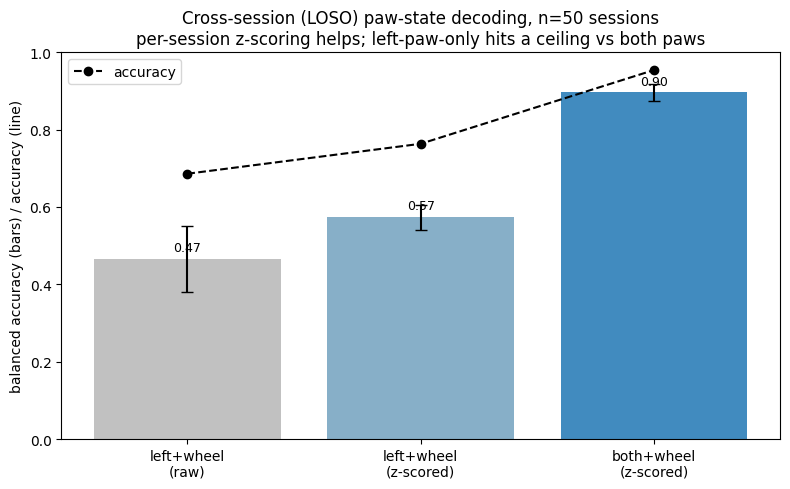

: 

In [ ]:
# ===== KEY FINDINGS: standardization & the left-paw feature ceiling (cross-session / LOSO) =====
# Self-contained comparison: reloads a few sessions WITH BOTH paws to contrast
#   left+wheel (raw)  vs  left+wheel (per-session z-scored)  vs  both+wheel (z-scored),
# under leave-one-session-out CV. Shows (a) per-session z-scoring helps and (b) left-paw-only
# hits a ceiling far below both-paw -> the missing right paw, not the model, is the limit.

kf_scales = ['0.5', '1.0', '2.0', '4.0', '8.0']
kf_lcols = [f'l_paw_{a}{s}' for a in ('x', 'y') for s in kf_scales]
kf_rcols = [f'r_paw_{a}{s}' for a in ('x', 'y') for s in kf_scales]

def kf_load(session, mouse, zscore=True):
    p = save_states_path + str(optimal_k) + "_states_file_" + str(session) + '_' + mouse
    wf = paw_wavelet_path + "paw_vel_wavelets_" + str(session) + '_' + mouse
    if not (Path(p).exists() and Path(wf).exists()):
        return None
    st = pd.read_parquet(p, columns=['Bin', 'avg_wheel_vel', 'identifiable_states'])
    wv = pd.read_parquet(wf, columns=['Bin'] + kf_lcols + kf_rcols)
    d = st.merge(wv, on='Bin', how='inner')
    d['paw_state'] = d['identifiable_states'].astype(str).str[0]
    d = d[d['paw_state'].str.isdigit()].copy().dropna(subset=['avg_wheel_vel'] + kf_lcols + kf_rcols)
    d['paw_state'] = d['paw_state'].astype(int)
    if zscore:
        for cols in (kf_lcols, kf_rcols):
            mu = d[cols].mean(); sd = d[cols].std().replace(0, 1)
            d[cols] = (d[cols] - mu) / sd
    return d

def kf_loso(sessions_dict, feat, n_sub=5000, seed=0):
    ks = list(sessions_dict); accs, bals = [], []
    for tk in ks:
        tr = pd.concat([sessions_dict[k].sample(n=min(n_sub, len(sessions_dict[k])), random_state=seed)
                        for k in ks if k != tk], ignore_index=True)
        te = sessions_dict[tk]
        clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=seed).fit(
            tr[feat].to_numpy(), tr['paw_state'].to_numpy())
        yp = clf.predict(te[feat].to_numpy()); yt = te['paw_state'].to_numpy()
        accs.append(accuracy_score(yt, yp)); bals.append(balanced_accuracy_score(yt, yp))
    return np.mean(accs), np.std(accs), np.mean(bals), np.std(bals)

kf_n = 50
kf_zs, kf_raw = {}, {}
for mat in sessions_to_process:
    if len(kf_zs) >= kf_n:
        break
    mo, se = mat[0], mat[1]
    dz = kf_load(se, mo, zscore=True)
    if dz is None or dz['paw_state'].nunique() < 2:
        continue
    kf_zs[(se, mo)] = dz
    kf_raw[(se, mo)] = kf_load(se, mo, zscore=False)
print(f"{len(kf_zs)} sessions loaded for key-findings comparison")

kf_fL = ['avg_wheel_vel'] + kf_lcols
kf_fLR = ['avg_wheel_vel'] + kf_lcols + kf_rcols
kf_res = {
    'left+wheel\n(raw)':      kf_loso(kf_raw, kf_fL),
    'left+wheel\n(z-scored)': kf_loso(kf_zs, kf_fL),
    'both+wheel\n(z-scored)': kf_loso(kf_zs, kf_fLR),
}
for k, v in kf_res.items():
    print(f"{k.replace(chr(10), ' '):26} LOSO acc={v[0]:.3f}  bal={v[2]:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
kf_labels = list(kf_res); kf_x = np.arange(len(kf_labels))
kf_bal = [kf_res[k][2] for k in kf_labels]; kf_balsd = [kf_res[k][3] for k in kf_labels]
kf_acc = [kf_res[k][0] for k in kf_labels]
ax.bar(kf_x, kf_bal, yerr=kf_balsd, capsize=4, color=['#bbbbbb', '#7aa6c2', '#2c7fb8'], alpha=0.9)
ax.plot(kf_x, kf_acc, 'ko--', label='accuracy')
ax.set_xticks(kf_x, kf_labels)
ax.set_ylabel('balanced accuracy (bars) / accuracy (line)')
ax.set_ylim(0, 1)
ax.set_title(f'Cross-session (LOSO) paw-state decoding, n={len(kf_zs)} sessions\n'
             'per-session z-scoring helps; left-paw-only hits a ceiling vs both paws')
ax.legend(loc='upper left')
for i in range(len(kf_bal)):
    ax.text(i, kf_bal[i] + 0.02, f'{kf_bal[i]:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()